# California Housing

In [2]:
# Data handling
import numpy as np
np.random.seed(42)
import pandas as pd

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Sklearn - model selection
from sklearn.model_selection import train_test_split, GridSearchCV, KFold
from sklearn.pipeline import Pipeline

# Sklearn - preprocessing
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer

# Models
from sklearn.dummy import DummyRegressor
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet

# Metrics
from sklearn.metrics import mean_absolute_error, root_mean_squared_error, r2_score, silhouette_score

# Clustering 
from sklearn.cluster import KMeans


# Del 1 - Explorativ dataanalys (EDA)

## Läsa in och undersöka datasetet

Datasetet läses in och en första översikt görs med avseende på datatyper, antal observationer och saknade värden.


**Anlays**  
- Kolumnen `total_bedrooms` innehåller saknade värden (207 stycken). Dessa kommer senare att hanteras i modellpipen med `SimpleImputer`.

- Variablerna har olika skalor och vissa (t.ex. total_rooms och population) innehåller extrema värden, vilket hanteras med `StandardScaler` i senare steg.

In [3]:
df = pd.read_csv('housing.csv')

print('Missing values per column:')
print(df.isna().sum())

df.info()
df.describe().T

Missing values per column:
longitude               0
latitude                0
housing_median_age      0
total_rooms             0
total_bedrooms        207
population              0
households              0
median_income           0
median_house_value      0
ocean_proximity         0
dtype: int64
<class 'pandas.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  str    
dtypes: float6

,count,mean,std,min,25%,50%,75%,max
longitude,20640.0,-119.569704,2.003532,-124.3500,-121.8000,-118.4900,-118.01000,-114.3100
latitude,20640.0,35.631861,2.135952,32.5400,33.9300,34.2600,37.71000,41.9500
housing_median_age,20640.0,28.639486,12.585558,1.0000,18.0000,29.0000,37.00000,52.0000
total_rooms,20640.0,2635.763081,2181.615252,2.0000,1447.7500,2127.0000,3148.00000,39320.0000
total_bedrooms,20433.0,537.870553,421.385070,1.0000,296.0000,435.0000,647.00000,6445.0000
population,20640.0,1425.476744,1132.462122,3.0000,787.0000,1166.0000,1725.00000,35682.0000
households,20640.0,499.539680,382.329753,1.0000,280.0000,409.0000,605.00000,6082.0000
median_income,20640.0,3.870671,1.899822,0.4999,2.5634,3.5348,4.74325,15.0001
median_house_value,20640.0,206855.816909,115395.615874,14999.0000,119600.0000,179700.0000,264725.00000,500001.0000


## Feature engineering

Skapar nya relationella variabler för att bättre beskriva områdenas bostads- och befolkningsstruktur:  
- rooms_per_household – antal rum per hushåll  
- bedrooms_per_room – andel sovrum av totala rum  
- population_per_household – antal personer per hushåll

Dessa nya features kompletterar de ursprungliga totalsummorna och används både för KMeans-klustring och linjär regression för att ge modellen mer meningsfull information

In [4]:
df['rooms_per_household'] = df['total_rooms'] / df['households']
df['bedrooms_per_room'] = df['total_bedrooms'] / df['total_rooms']
df['population_per_household'] = df['population'] / df['households']

### Utvärdering av feature engineering

Tre olika feature-uppsättningar testades: endast originalvariabler, endast skapade variabler samt en kombination av båda.

Resultaten visade att modellen presterade bäst när både originalvariabler och de nya relationella variablerna användes tillsammans. Detta indikerar att de nya features tillför kompletterande information utan att ersätta de ursprungliga variablernas betydelse.

Därför används den kombinerade feature-uppsättningen i den slutliga modellen.


## Uppdelning av features och target

Målet i uppgiften är att förutsäga bostadsvärdet `median_house_value`.

Därför delas datasetet upp i:
- **X** – modellens features (inklusive nya och ursprungliga)
- **y** – targetvariabeln (`median_house_value`)


In [5]:

target_col = 'median_house_value'
             
X = df.drop(columns=[target_col])
y = df[target_col]

X.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,ocean_proximity,rooms_per_household,bedrooms_per_room,population_per_household
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,NEAR BAY,6.984127,0.146591,2.555556
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,NEAR BAY,6.238137,0.155797,2.109842
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,NEAR BAY,8.288136,0.129516,2.802260
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,NEAR BAY,5.817352,0.184458,2.547945
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,NEAR BAY,6.281853,0.172096,2.181467


## Fördelning av targetvariabeln

Histogrammet visar hur `median_house_value` är fördelad i datasetet.

Fördelningen är tydligt högerskev och många observationer ligger nära den övre gränsen på 500 000. Detta tyder på att datasetet innehåller ett takvärde (capping), vilket kan påverka modellens prediktioner för de dyraste områdena.

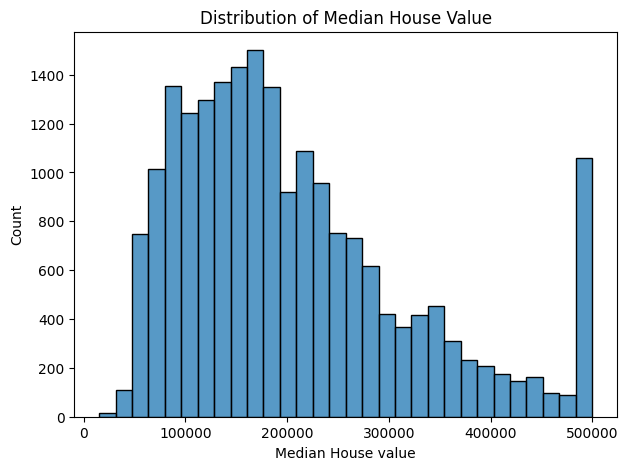

In [6]:
plt.figure(figsize=(7,5))
sns.histplot(y, bins=30)
plt.title('Distribution of Median House Value')
plt.xlabel('Median House value')
plt.show()

## Sambandsanalys

**Korrelationsmatrisen** visar: 
- median_income har det starkaste positiva sambandet med bostadsvärde.
- Flera storleksrelaterade variabler (t.ex. total_rooms, population och households) är starkt korrelerade med varandra.
- En negativ korrelation mellan bedrooms_per_room och bostadsvärdet, vilket indikerar att områden med hög andel sovrum per rum ofta är billigare

**Boxploten** visar:
- Områden nära havet generellt har högre bostadspriser än inlandet.


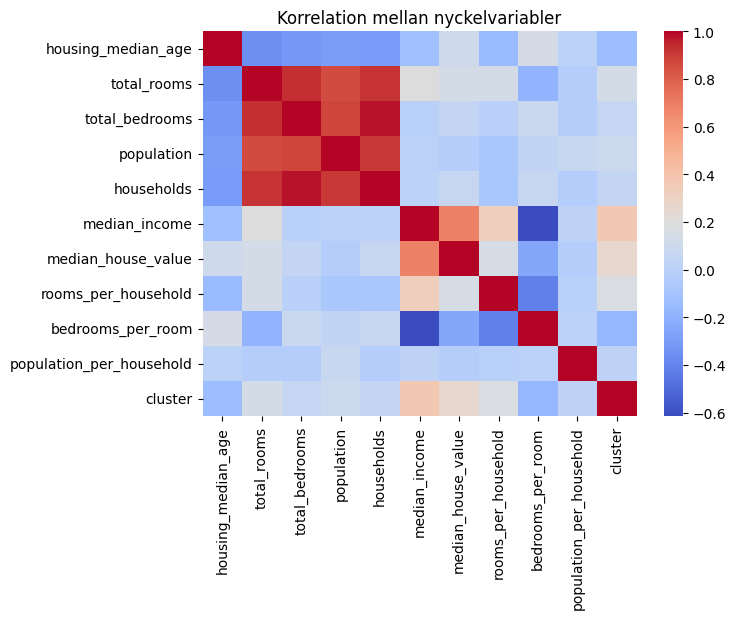

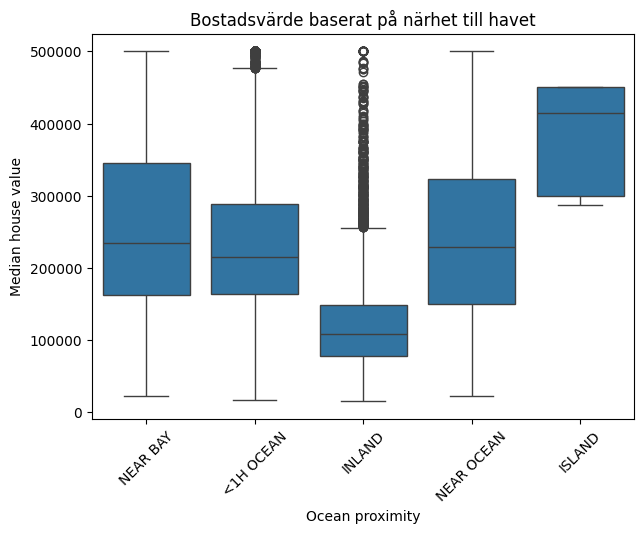

In [26]:
plt.figure(figsize=(7, 5))
sns.heatmap(df.drop(columns=['longitude', 'latitude']).corr(numeric_only=True), annot=False, cmap='coolwarm')
plt.title('Korrelation mellan nyckelvariabler')
plt.show()

# 2. Boxplot för att visa kategoriskt samband (ocean_proximity vs pris)
plt.figure(figsize=(7, 5))
sns.boxplot(x='ocean_proximity', y='median_house_value', data=df)
plt.title('Bostadsvärde baserat på närhet till havet')
plt.xlabel('Ocean proximity')
plt.ylabel('Median house value')
plt.xticks(rotation=45)
plt.show()

## Samband mellan inkomst och bostadsvärde

Scatterploten visar sambandet mellan `median_income` och `median_house_value`.

Det finns ett tydligt positivt samband: områden med högre medianinkomst tenderar att ha högre bostadsvärden. Samtidigt finns en viss spridning, vilket visar att fler faktorer än inkomst påverkar priset.

Det syns också ett tydligt tak vid 500 000, vilket bekräftar att datasetet innehåller censurerade värden.

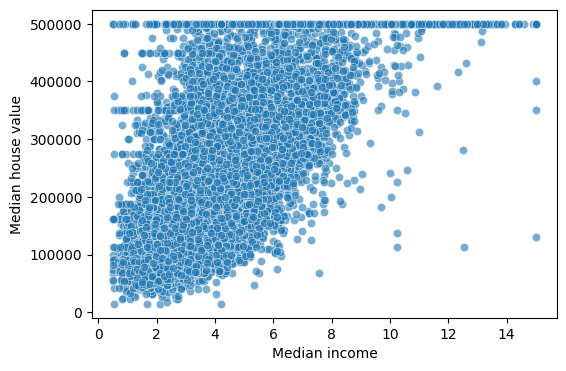

In [8]:
plt.figure(figsize=(6, 4))
sns.scatterplot(x='median_income', y='median_house_value', data=df, alpha=0.6)
plt.xlabel('Median income')
plt.ylabel('Median house value')
plt.show()

# Del 2 - Oövervakad inlärning – KMeans
För att undersöka om det finns naturliga grupperingar i datasetet används KMeans-klustring.  
Målet är att identifiera olika typer av bostadsområden baserat på geografiska och socioekonomiska egenskaper.

## Väljer features till Kmean

Jag väljer ut de variabler som beskriver:
- geografiskt läge
- bostädernas ålder
- områdets inkomstnivå

Variabler med stark inbördes korrelation (t.ex. total_rooms och population) exkluderas för att minska redundans i klustringen.

In [9]:
features_for_kmeans = [
    'longitude', 'latitude', 
    'housing_median_age', 'median_income', 
    'rooms_per_household', 'bedrooms_per_room', 'population_per_household'
]

X_kmeans = df[features_for_kmeans]

## Förbehandling av data

KMeans är känslig för olika skalor i datan. Därför görs två steg innan modellen tränas:

1. Saknade värden fylls i med medianen.
2. Variablerna skalas med `StandardScaler`.

Detta gör att alla variabler får jämförbara värden och kan bidra lika mycket till klustringen.

In [10]:
imputer = SimpleImputer(strategy='median')
X_kmeans_imputed = imputer.fit_transform(X_kmeans)

scaler = StandardScaler()
X_kmeans_scaled = scaler.fit_transform(X_kmeans_imputed)

## Val av antal kluster – Elbow-metoden

För att uppskatta ett lämpligt antal kluster används Elbow-metoden.

Metoden mäter modellens **inertia**, vilket är summan av avstånden mellan varje punkt och dess klustercentrum. 

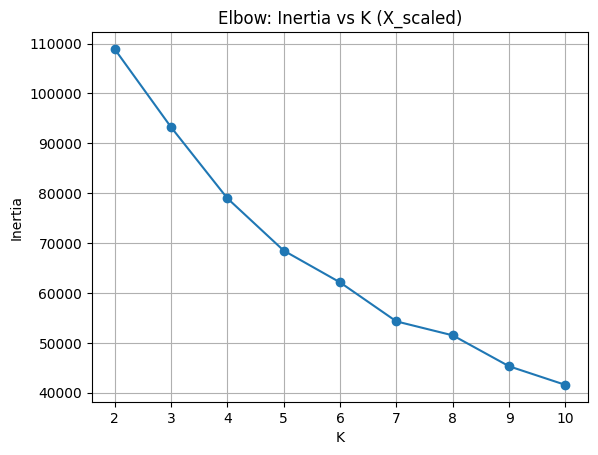

In [11]:
inertias = []
K_range = range(2, 11) 

for K in K_range:
    km = KMeans(n_clusters=K, random_state=42, n_init=10)
    km.fit(X_kmeans_scaled)
    inertias.append(km.inertia_)

plt.figure()
plt.plot(list(K_range), inertias, marker='o')
plt.xlabel('K')
plt.ylabel('Inertia')
plt.title('Elbow: Inertia vs K (X_scaled)')
plt.grid(True)
plt.show()

##  Val av antal kluster – Silhouette score

För att komplettera Elbow-metoden beräknas även **silhouette score**.

Silhouette-värdet mäter hur väl varje datapunkt passar i sitt kluster jämfört med andra kluster.  

Genom att jämföra silhouette-värden för olika antal kluster kan ett mer stabilt val göras.

,K,inertia,silhouette
0,2,108933.884010,0.335311
1,3,93276.490815,0.302796
2,4,78999.615415,0.303088
3,5,68508.633336,0.260242
4,6,62133.006008,0.254330
5,7,54311.864899,0.256276
6,8,51512.086429,0.251558
7,9,45310.195364,0.259359
8,10,41575.835572,0.260361


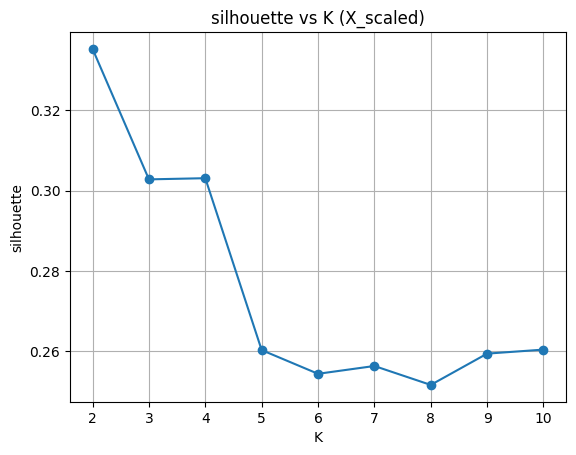

In [12]:
results = []


for K in range(2, 11):
    km = KMeans(n_clusters=K, random_state=42, n_init=10) 
    labels = km.fit_predict(X_kmeans_scaled)
    sil = silhouette_score(X_kmeans_scaled, labels)
    results.append({'K': K, 'inertia': km.inertia_, 'silhouette': sil})

results_df = pd.DataFrame(results)
display(results_df)

plt.figure()
plt.plot(results_df['K'], results_df['silhouette'], marker='o')
plt.xlabel('K')
plt.ylabel('silhouette')
plt.title('silhouette vs K (X_scaled)')
plt.grid(True)
plt.show()

### Analys av Elbow och Silhouette samt val av antal kluster

Elbow-metoden indikerar ett lämpligt intervall kring 4–5 kluster, medan silhouette score är högst vid 2 men relativt likt för 3–4 kluster.

Vid analys av resultaten visade sig 4 kluster innehålla en outlier (ett kluster med endast en observation), vilket tyder på instabil klustring.

Därför valdes **3 kluster** som en mer robust och tolkbar lösning.

## Slutlig KMeans-modell och klusterprofilering

Efter att modellen tränats tilldelas varje område ett kluster.  
För att förstå skillnaderna mellan klustren analyseras genomsnittliga värden för några centrala variabler, exempelvis:

- medianinkomst
- rum per hushåll
- bostädernas ålder
- medianvärde på bostäder

Detta ger en enkel profil av olika typer av områden i datasetet.

**Targetvariabeln** används **endast** i efteranalysen för att tolka klustren och ingår inte i själva klustringsprocessen.

In [13]:
# Träna slutgiltig KMeans-modell
kmeans_final = KMeans(n_clusters=3, random_state=42, n_init=10)

# Tilldela varje observation ett kluster
df["cluster"] = kmeans_final.fit_predict(X_kmeans_scaled)

# Skapa klusterprofiler (genomsnitt per kluster)
cluster_profile = df.groupby("cluster").mean(numeric_only=True)

# Variabler vi vill jämföra mellan kluster
cols_to_show = [
    "median_income",
    "rooms_per_household",
    "bedrooms_per_room",
    "population_per_household",
    "housing_median_age",
    "median_house_value"
]

print(df['cluster'].value_counts().sort_index())

display(cluster_profile[cols_to_show].round(2))

cluster
0    8245
1    7567
2    4828
Name: count, dtype: int64


,median_income,rooms_per_household,bedrooms_per_room,population_per_household,housing_median_age,median_house_value
cluster,,,,,,
0,3.65,5.47,0.20,2.88,29.14,191805.54
1,2.84,4.43,0.25,3.10,31.30,177564.31
2,5.85,6.92,0.17,3.34,23.61,278466.91


### Tolkning av kluster

Genom att analysera genomsnittsvärdena för varje kluster kan olika typer av områden identifieras i datasetet.

**Kluster 0**  
Detta kluster har medelhöga värden för både medianinkomst (≈3.65) och bostadspriser (≈192k). Antalet rum per hushåll ligger också på en genomsnittlig nivå. Klustret kan därför tolkas som relativt typiska bostadsområden i datasetet.

**Kluster 1**  
Detta kluster har lägst medianinkomst (≈2.84) och även de lägsta bostadspriserna (≈178k). Antalet rum per hushåll är lägre och andelen sovrum per rum något högre, vilket kan tyda på mindre eller mer tätt utnyttjade bostäder. Klustret kan därför representera områden med mer begränsade resurser.

**Kluster 2**  
Här återfinns de högsta värdena för både medianinkomst (≈5.85) och bostadspriser (≈278k). Områdena har också flest rum per hushåll och en lägre andel sovrum per rum, vilket kan tyda på större bostäder. Detta kluster kan därför tolkas som mer välbärgade områden.

**Sammanfattningsvis** visar klustringen att datasetet innehåller olika typer av bostadsområden, med tydliga skillnader i inkomstnivåer och bostadspriser. Detta stärker bilden från den tidigare korrelationsanalysen där medianinkomst visade ett starkt samband med bostadsvärde.

## Geografisk visualisering av kluster

Eftersom datasetet innehåller geografiska koordinater (longitude och latitude) kan klustren visualiseras geografiskt.


Genom att plotta varje område efter dess position och färga punkterna efter klustertillhörighet kan jag undersöka om olika typer av områden tenderar att ligga i olika delar av Kalifornien.

Visualiseringen kan exempelvis visa om vissa kluster främst finns nära kusten eller i inlandet.

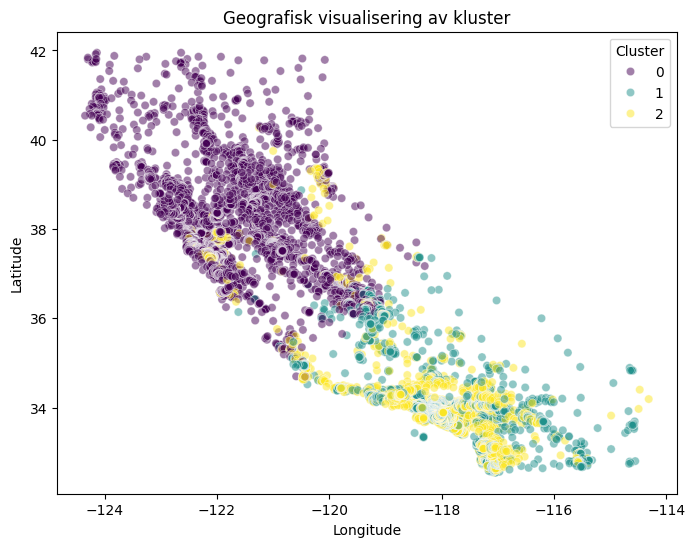

In [14]:
plt.figure(figsize=(8,6))
sns.scatterplot(
    x="longitude",
    y="latitude",
    hue="cluster",
    palette='viridis',
    data=df,
    alpha=0.5
)

plt.title("Geografisk visualisering av kluster")
plt.xlabel("Longitude")
plt.ylabel("Latitude")

plt.legend(title="Cluster")
plt.show()

### Tolkning av den geografiska visualiseringen

**Kluster 2 – kustnära och högre priser**  
Detta kluster är främst koncentrerat längs kusten, särskilt kring större städer som området runt San Francisco och delar av södra Kalifornien. Dessa områden har även högst medianinkomst och bostadspriser.

**Kluster 1 – inland och lägre priser**  
Detta kluster dominerar mer inlandet och de centrala delarna av delstaten. Här är både medianinkomst och bostadspriser generellt lägre.

**Kluster 0 – norra områden med mellannivåer**  
Detta kluster bildar en tydlig grupp i de nordvästra delarna av kartan. Områdena har mer genomsnittliga nivåer för både inkomst och bostadspriser.

Sammanfattningsvis tyder visualiseringen på att geografiskt läge, särskilt närhet till kusten, hänger ihop med högre bostadspriser i datasetet.

# Del 3 - Modellträning och utvärdering

## Train/Test-split  
- Delar upp datan i tränings- och testmängd (80/20) för att kunna utvärdera modellen på osedd data.
- Kontrollerar shape för att verifiera att splitten genomförts korrekt.

In [15]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
)

print('Train shape: ', X_train.shape)
print('Test shape: ', X_test.shape)

Train shape:  (16512, 12)
Test shape:  (4128, 12)


## Identifiering av variabeltyper

Features delas upp i numeriska och kategoriska variabler baserat på datatyp.

**Verifiering**: Efter feature engineering består datasetet av 12 features, vilket bekräftas genom kontroll av numeriska och kategoriska variabler.

In [16]:
# Identifierar kolumner baserat på datatyp
numeric_features = X.select_dtypes(include=['number']).columns
categorical_features = X.select_dtypes(include=['object', 'string']).columns

# Kontroll av antal för att matcha EDA
print(f'Antal numeriska: {len(numeric_features)}')
print(f'Antal kategoriska: {len(categorical_features)}')
print(f'Total features (ny lista): {len(numeric_features) + len(categorical_features)}')
print(f'Total features (verifiering): {X.shape[1]}')

print(f'\nNumeriska variabler: \n{numeric_features}')
print(f'\nKategoriska variabler: \n{categorical_features}')

Antal numeriska: 11
Antal kategoriska: 1
Total features (ny lista): 12
Total features (verifiering): 12

Numeriska variabler: 
Index(['longitude', 'latitude', 'housing_median_age', 'total_rooms',
       'total_bedrooms', 'population', 'households', 'median_income',
       'rooms_per_household', 'bedrooms_per_room', 'population_per_household'],
      dtype='str')

Kategoriska variabler: 
Index(['ocean_proximity'], dtype='str')


## Preprocessing Pipeline

**Numerisk hantering**:
- saknade värden fylls med median
- variablerna skalas med `StandardScaler`

**Kategorisk hantering**:  
- saknade värden fylls med vanligaste värdet
- kategorier kodas med `OneHotEncoder`

**Driftsäkerhet**: Parametern handle_unknown='ignore' inkluderas för att hantera nya kategorier i framtida data utan att pipelinen avbryts.

**Exkludering av övrig data**: Med remainder='drop' säkerställer vi att endast de features vi valt ut (de i numeric_features och categorical_features) skickas vidare till modellen

**Preprocessingen** samlas i en `ColumnTransformer` så att samma steg automatiskt appliceras under modellträning och prediktion.

In [17]:
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features)
    ],
    remainder= 'drop'
)

## Val av utvärderingsmått
RMSE används som huvudmått eftersom det straffar stora fel mer än små. I detta case är stora fel (t.ex. felvärdering av dyra områden) särskilt problematiska, vilket gör RMSE mer lämpligt än exempelvis MAE.

MAE och R² används som komplement för att ge en mer komplett bild av modellens prestanda.

## Utvärderingsfunktion för regression

Skapar en funktion för att utvärdera regressionsmodeller.

Beräknar:
- **RMSE** – rot-mean-squered-error (straffar stora fel mer)
- **MAE** – mean-absolute-error
- **R²** – Andel av variationen i datan som modellen förklarar

Resultatet returneras som en dictionary som kan användas för att jämföra modeller.

In [18]:
def eval_regression(y_true, y_pred, model_name: str) -> dict:
    """
    Utvärderar en regressionsmodell.
    
    Parametrar:
    y_true : riktiga värden
    y_pred : prediktioner
    model_name : namn på modellen
    
    Returnerar:
    dict med RMSE, MAE, R2
    """
    rmse = root_mean_squared_error(y_true, y_pred)
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)

    return {'Model': model_name, 'RMSE': rmse, 'MAE': mae, 'R2': r2}

## Baseline-modell

Tränar en baseline-modell (`DummyRegressor`) som predikterar medelvärdet av target.

Syfte:
- Jämförelsepunkt för RMSE, MAE och R²
- Kontrollera att modellerna lär sig något utöver medelvärdet

In [19]:
baseline = DummyRegressor(strategy='mean')

baseline.fit(X_train, y_train)

y_pred_baseline= baseline.predict(X_test)

baseline_results = eval_regression(
    y_true=y_test,
    y_pred=y_pred_baseline,
    model_name='Baseline (mean)'
)

print("Model:", baseline_results['Model'])
print("RMSE:", round(baseline_results['RMSE'], 2))
print("MAE:", round(baseline_results['MAE'], 2))
print("R2:", round(baseline_results['R2'], 3))   


Model: Baseline (mean)
RMSE: 114485.64
MAE: 90606.85
R2: -0.0


## Skapa pipelines och parametrar

Skapar pipelines och hyperparametrar för fyra regressionsmodeller:
- LinearRegression (ingen hyperparameter)
- Ridge
- Lasso
- ElasticNet

Alla pipelines inkluderar samma preprocessing för numeriska och kategoriska variabler.


In [20]:
# LinearRegresson
linear_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', LinearRegression())
])

param_grid_linear = {} 


# Ridge
ridge_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', Ridge())
])

param_grid_ridge = {
    'regressor__alpha': [0.1, 1.0, 10.0, 50.0, 100.0]
}


# Lasso
lasso_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', Lasso(max_iter=10000))
])

param_grid_lasso = {
    'regressor__alpha': [0.001, 0.01, 0.1, 1.0, 10.0]
}


# ElasticNet
elastic_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', ElasticNet(max_iter=10000))
])

param_grid_elastic = {
    'regressor__alpha': [0.001, 0.01, 0.1, 1.0],
    'regressor__l1_ratio': [0.2, 0.5, 0.8]
}


## Funktion för modellutvärdering med GridSearchCV

Funktionen `run_grid_search`:
- Kör 5-faldig cross-validation på angiven pipeline
- Optimerar RMSE (via neg_root_mean_squared_error)
- Returnerar bästa modell och hyperparametrar

In [21]:
cv_strategy = KFold(n_splits=5, shuffle=True, random_state=42)

def run_grid_search(pipeline, param_grid, model_name):
    """
    Kör GridSearchCV för en given pipeline och parameter-grid.
    Returnerar bästa estimator och skriver ut resultat.
    """
    grid_search = GridSearchCV(
        estimator=pipeline,
        param_grid=param_grid,
        scoring='neg_root_mean_squared_error',
        cv=cv_strategy,
        n_jobs=-1
    )
    grid_search.fit(X_train, y_train)
    print(f"\n=== {model_name} ===")
    print("Best CV RMSE:", -grid_search.best_score_)
    print("Best Params:", grid_search.best_params_)
    return grid_search


## Körning av GridSearch och modelljämförelse

Kör GridSearchCV för alla fyra modeller och jämför deras prestanda enligt CV-RMSE.

Bästa modell väljs ut baserat på lägst CV-RMSE och används för slutlig utvärdering på testdata.

In [22]:
# Kör GridSearch för alla modeller
linear_grid = run_grid_search(linear_pipeline, param_grid_linear, 'Linear Regression')
ridge_grid = run_grid_search(ridge_pipeline, param_grid_ridge, 'Ridge Regression')
lasso_grid = run_grid_search(lasso_pipeline, param_grid_lasso, 'Lasso Regression')
elastic_grid = run_grid_search(elastic_pipeline, param_grid_elastic, 'ElasticNet')

# Sammanställ CV-resultat
cv_results = [
    {'model': 'Linear Regression','CV_RMSE': -linear_grid.best_score_},
    {'model': 'Ridge','CV_RMSE': -ridge_grid.best_score_},
    {'model': 'Lasso','CV_RMSE': -lasso_grid.best_score_},
    {'model': 'ElasticNet','CV_RMSE': -elastic_grid.best_score_}
]

cv_results_df = pd.DataFrame(cv_results).sort_values('CV_RMSE')
display(cv_results_df)

# Välj bästa modell
best_model_name = cv_results_df.iloc[0]['model']
best_estimator_lookup = {
    'Linear Regression': linear_grid.best_estimator_,
    'Ridge': ridge_grid.best_estimator_,
    'Lasso': lasso_grid.best_estimator_,
    'ElasticNet': elastic_grid.best_estimator_,
}
best_model = best_estimator_lookup[best_model_name]

print('Bästa modell enligt CV:', best_model_name)
best_model



=== Linear Regression ===
Best CV RMSE: 67858.77852206837
Best Params: {}

=== Ridge Regression ===
Best CV RMSE: 67849.2034487093
Best Params: {'regressor__alpha': 1.0}

=== Lasso Regression ===
Best CV RMSE: 67851.43739050339
Best Params: {'regressor__alpha': 10.0}

=== ElasticNet ===
Best CV RMSE: 67847.5469533751
Best Params: {'regressor__alpha': 0.001, 'regressor__l1_ratio': 0.8}


,model,CV_RMSE
3,ElasticNet,67847.546953
1,Ridge,67849.203449
2,Lasso,67851.437391
0,Linear Regression,67858.778522


Bästa modell enligt CV: ElasticNet


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('regressor', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformer

### Analys av modellprestanda (Cross-Validation)

Samtliga modeller presterar likartat, med RMSE runt **67 800**, vilket tyder på att sambanden i datan till stor del kan fångas av en enkel linjär modell. Regulariserade modeller (Ridge, Lasso och Elastic Net) ger endast marginella förbättringar jämfört med vanlig linjär regression.

Bäst resultat gav **Elastic Net** med CV-RMSE cirka **67 847**. Elastic Net kombinerar Ridge- och Lasso-regularisering, vilket gör modellen robust mot korrelerade variabler – något vi observerat i vår data.

Skillnaderna är små och resultaten stabila oavsett modellval. Elastic Net väljs som slutmodell då den ger lägst genomsnittligt prediktionsfel vid korsvalidering.


# Del 4 - Test och slutlig utvärdering

## Prediktion på testdata
Modellen utvärderas på testdata som inte använts under träning för att få en realistisk bild av dess prestanda på ny, osedd data.

Resultaten beräknas med samma regressionsmått (RMSE, MAE, R²) som vid korsvalidering

In [23]:
y_pred_test = best_model.predict(X_test)

test_results = eval_regression(
    y_true=y_test,
    y_pred=y_pred_test,
    model_name=f'Best model on test: {best_model_name}'
)

test_results

{'Model': 'Best model on test: ElasticNet',
 'RMSE': 69149.18962994686,
 'MAE': 49660.585599626014,
 'R2': 0.6351054895169285}

## Analys av testdata

Resultaten från testutvärderingen visar:

- **RMSE ≈ 69 149**
- **MAE ≈ 49 661**
- **R² ≈ 0.635**

RMSE-värdet är något högre än under cross-validation (≈ 67 847). 
Skillnaden är dock relativt liten, vilket tyder på att modellen **generaliserar väl och inte är kraftigt överanpassad till träningsdatan**.

MAE-värdet innebär att modellen i genomsnitt gör ett fel på ungefär **50 000 USD** när den uppskattar medianvärdet på bostäder i ett område. Med tanke på att bostadspriserna i datasetet sträcker sig upp till cirka **500 000 USD**, ger modellen en relativt rimlig uppskattning av prisnivåerna.

R²-värdet på **0.64** innebär att modellen kan förklara ungefär **64 % av variationen i bostadspriserna** baserat på de tillgängliga variablerna. Detta tyder på att faktorer som inkomstnivå, geografi och bostadsstruktur har ett betydande samband med bostadspriserna, men också att andra faktorer (som inte finns i datasetet) sannolikt påverkar prisbildningen.

## Predicted vs Actual

Scatterploten visar att modellen fångar den övergripande trenden väl.

Observationer:

- Felmarginalen ökar vid högre priser (heteroskedasticitet)
- Dyra bostäder underskattas systematiskt (tak vid 500 000)
- Vissa negativa prediktioner → begränsning i linjär modell

**Slutsats:**  
Modellen fungerar bra generellt men har svårt med extrema värden. Icke-linjära modeller kan förbättra detta.

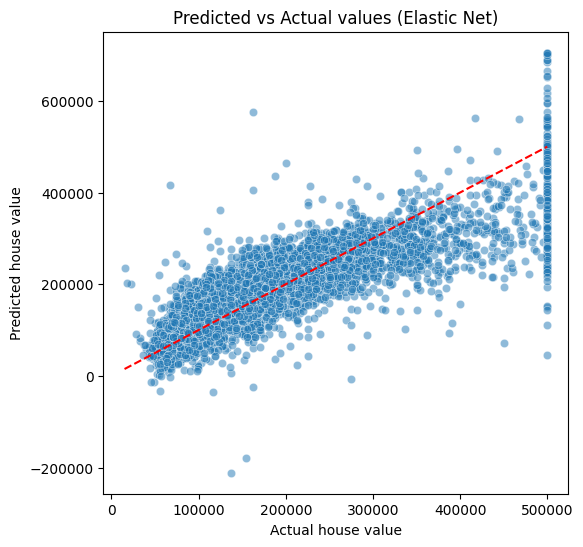

In [24]:
plt.figure(figsize=(6,6))

sns.scatterplot(
    x=y_test,
    y=y_pred_test,
    alpha=0.5
)

# perfekt prediktionslinje
plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    color='red',
    linestyle='--'
)

plt.xlabel("Actual house value")
plt.ylabel("Predicted house value")
plt.title("Predicted vs Actual values (Elastic Net)")

plt.show()

## Residualanalys
Residualerna (skillnaden mellan faktiskt och förutsagt värde) bör vara slumpmässigt spridda kring noll-linjen för en välfungerande modell.

Observationer:

- Ett tydligt mönster syns i residualplottet istället för slumpmässig spridning, vilket visar att modellen missar viktiga samband i datan.
- Spridningen av residualerna ökar kraftigt vid högre förutsagda värden, vilket innebär sämre precision för de dyrare husen.
- Den diagonala strukturen i plottet beror troligen på ett takvärde (cap) i datan som skapar systematiska avvikelser.
- Förekomsten av negativa prediktioner avslöjar en tydlig begränsning hos modellen, eftersom huspriser inte kan vara negativa.

**Slutsats:** 
Modellen fångar inte alla samband i datan, vilket tyder på att mer komplexa modeller kan ge bättre resultat.

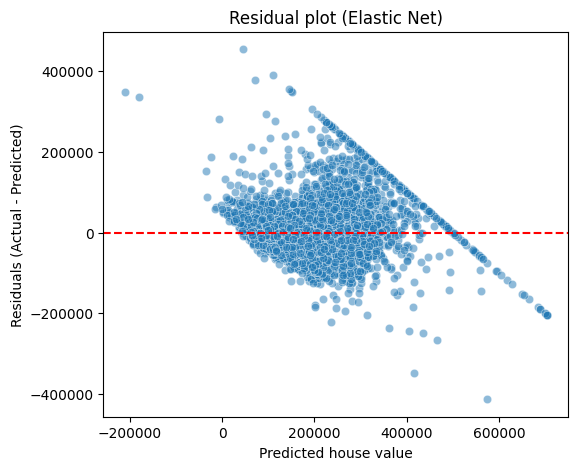

In [25]:
# Beräkna residualer
residuals = y_test - y_pred_test

plt.figure(figsize=(6,5))

sns.scatterplot(
    x=y_pred_test,
    y=residuals,
    alpha=0.5
)

plt.axhline(0, color='red', linestyle='--')

plt.xlabel("Predicted house value")
plt.ylabel("Residuals (Actual - Predicted)")
plt.title("Residual plot (Elastic Net)")

plt.show()

## Sammanfattande slutsats

Syftet var att undersöka om maskininlärning kan användas för att uppskatta bostadsvärden i olika områden i Kalifornien baserat på geografiska och socioekonomiska faktorer.

Analysen visade att medianinkomst har starkast samband med bostadspris, och att kustnära områden generellt har högre värden. Datasetet innehåller även ett pristak vid 500 000 USD, vilket påverkar modellens prediktioner för de dyraste områdena.

Flera linjära regressionsmodeller tränades och jämfördes med hjälp av 5-faldig cross-validation. Samtliga modeller presterade relativt likartat, men **Elastic Net** uppnådde den lägsta genomsnittliga RMSE och valdes därför som slutlig modell. Efter hyperparameter-optimering utvärderades modellen på testdata, där den uppnådde:

- RMSE ≈ 69 149  
- MAE ≈ 49 661  
- R² ≈ 0.64

Modellen förklarar därmed cirka 64 % av variationen i bostadspriser och ger rimliga uppskattningar på områdesnivå.  
Det genomsnittliga absoluta felet på cirka 50 000 USD innebär dock att modellen främst bör användas som ett **övergripande beslutsstöd**, snarare än för exakt värdering av enskilda bostäder.

En kompletterande analys med KMeans identifierade tre tydliga typer av områden (höginkomst/kust, genomsnittliga, samt låginkomst/inland), vilket ger ytterligare stöd för att förstå och segmentera marknaden.

Rekommendation:
Modellen kan användas för att snabbt uppskatta prisnivåer och identifiera attraktiva områden. För mer precisa prediktioner bör mer avancerade (icke-linjära) modeller samt fler variabler övervägas.
